# Token count as a proxy for reasoning effort

In [1]:
%run -i "utils.py"

In [2]:
df = load_results("../data/qr2025/large")

Restrict ourselves to these LRMs:

In [3]:
reasoning_models = [
    "azure-o1-2024-12-17",
    "azure-o3-mini-2025-01-31",
    "azure-o3-mini-2025-01-31-high",
    "azure-o4-mini-2025-04-16",
    "deepseek-reasoner"
]

df = df[df['model'].isin(reasoning_models)]

Extract completion tokens and reasoning tokens

In [4]:
df.loc[:, 'completion_tokens'] = df['response'].apply(
    lambda x: x.get('usage', {}).get('completion_tokens', 0)
)

df.loc[:, 'reasoning_tokens'] = df['response'].apply(
    lambda x: x.get('usage', {})
                .get('completion_tokens_details', {})
                .get('reasoning_tokens', 0)
)

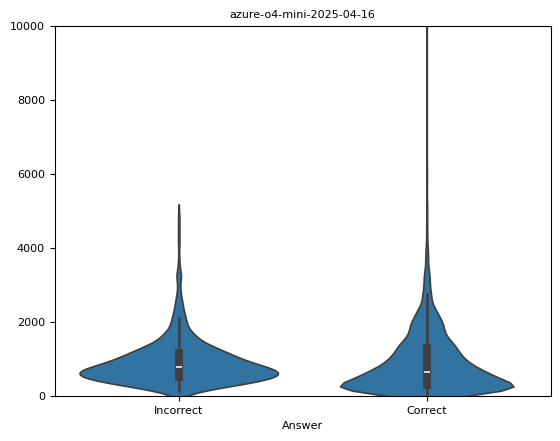

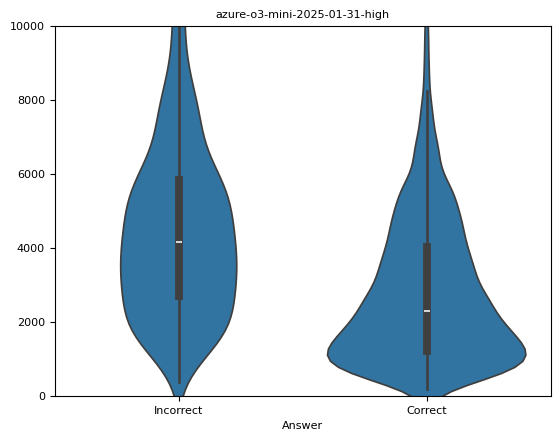

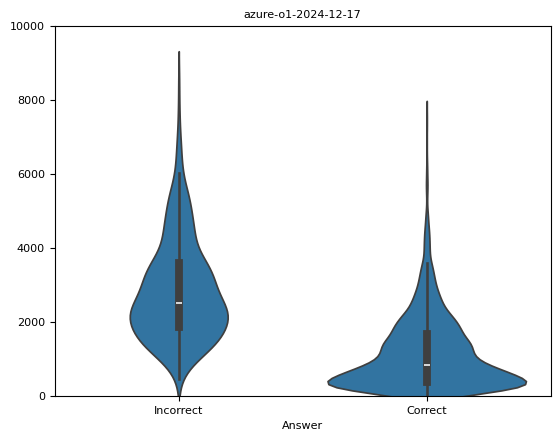

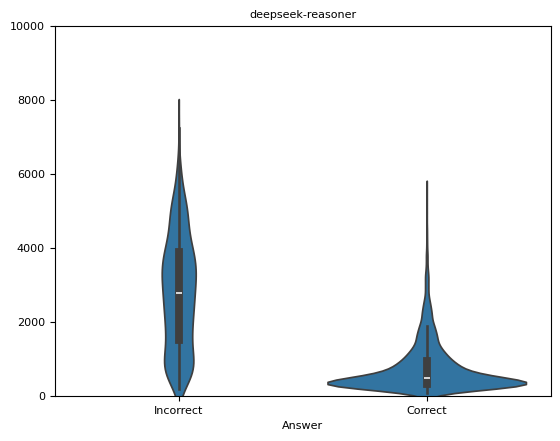

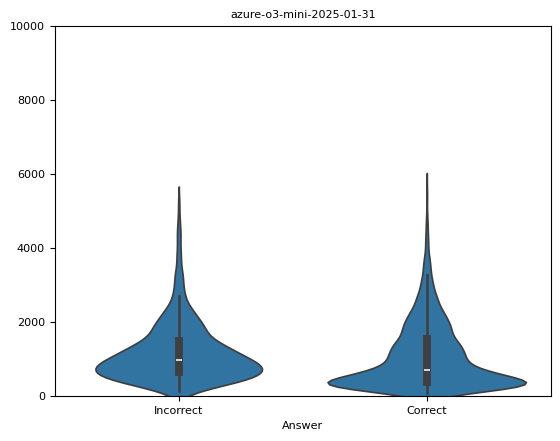

In [5]:
for model in df['model'].unique():
    plot_reasoning_tokens(df[df["model"] == model], model)

o4-mini has a slightly lower median for correct compared to incorrect answers but has a very long  but small tail of correct answers requiring a very large number of reasoning tokens. 

In [19]:
df2 = df[df["model"] == "azure-o4-mini-2025-04-16"]
print(len(df2[(df2['reasoning_tokens'] > 4864) & (df2['score'] == 1)]))
print(len(df2[(df2['reasoning_tokens'] > 4864) & (df2['score'] == 0)]))
print(df2[df2['score'] == 1]['reasoning_tokens'].max())
print(df2[df2['score'] == 0]['reasoning_tokens'].max())


18
0
10432
4864


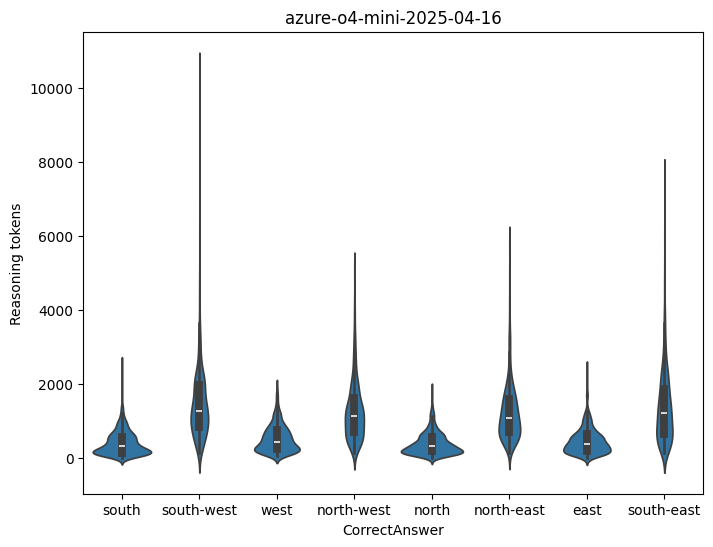

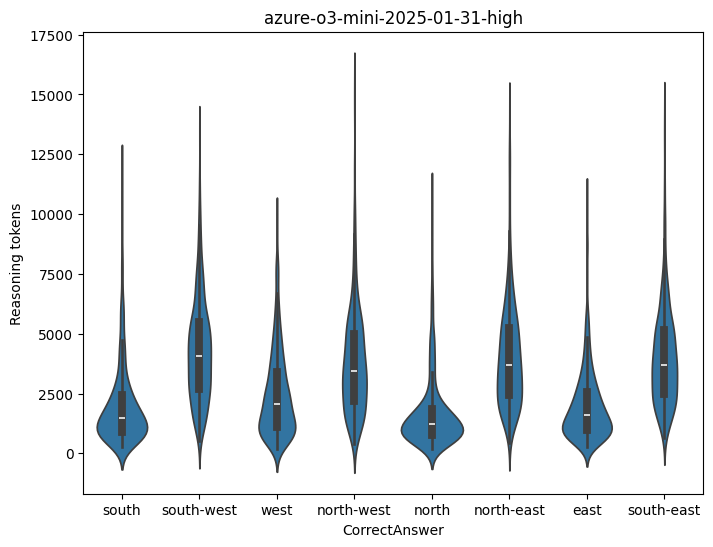

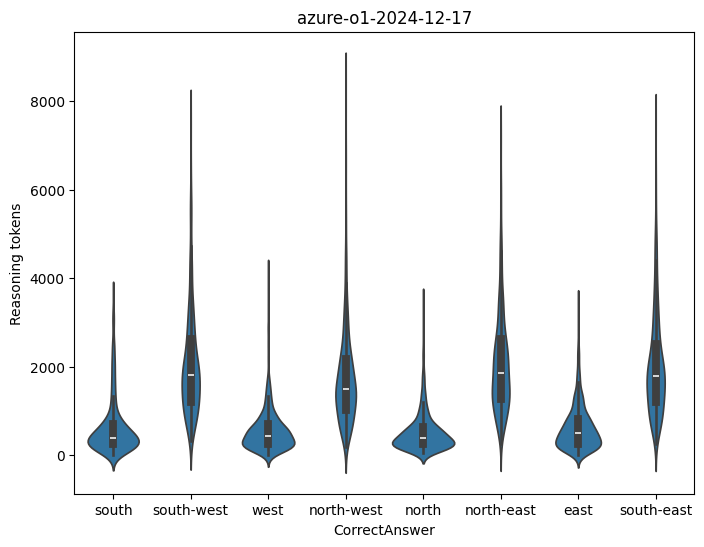

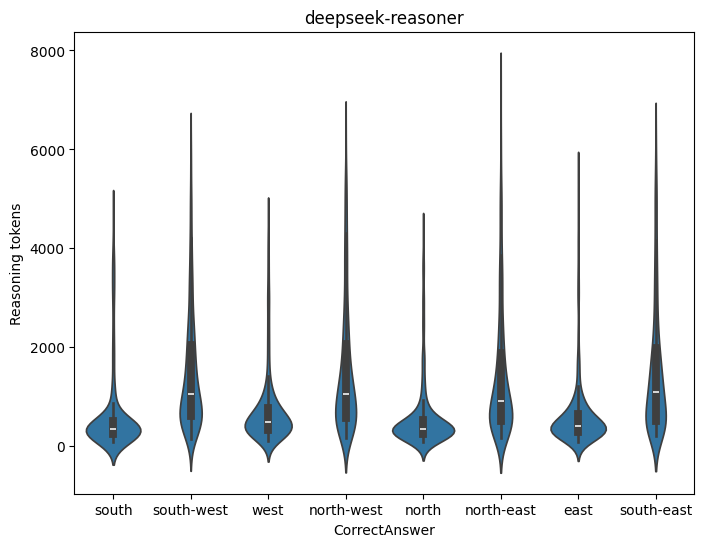

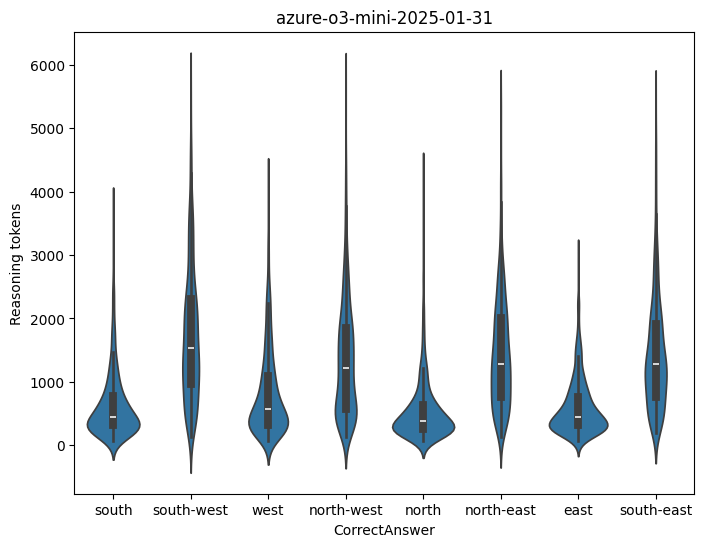

In [6]:
for model in df['model'].unique():
    plot_direction_violin(df[df['model'] == model], model)

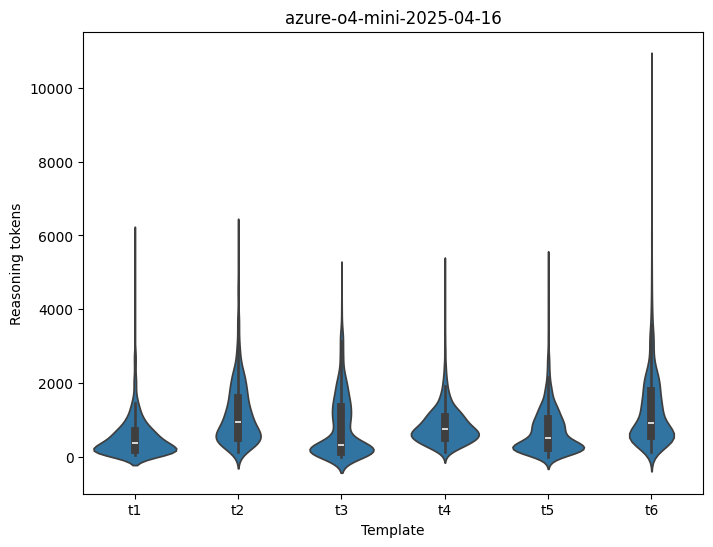

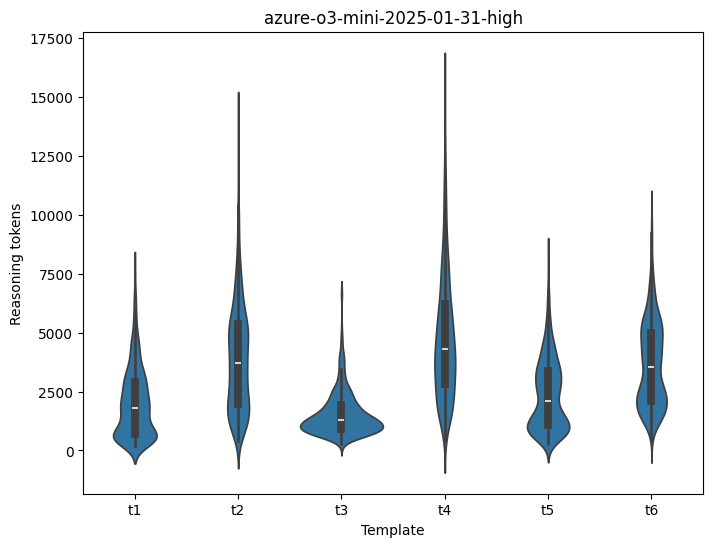

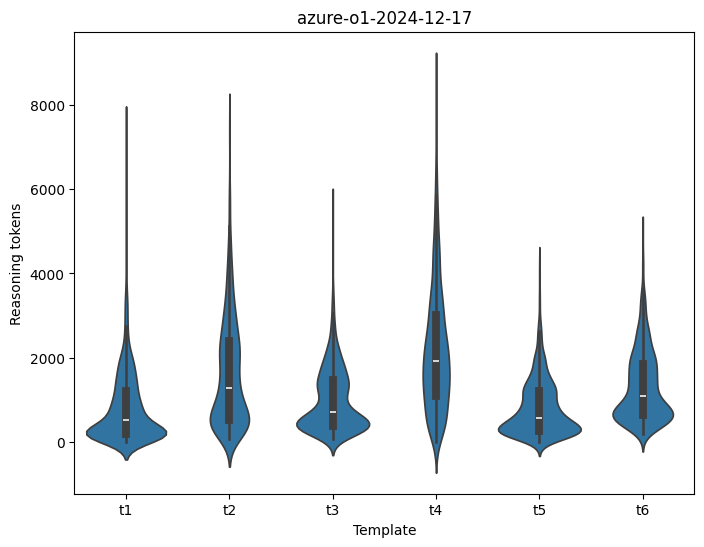

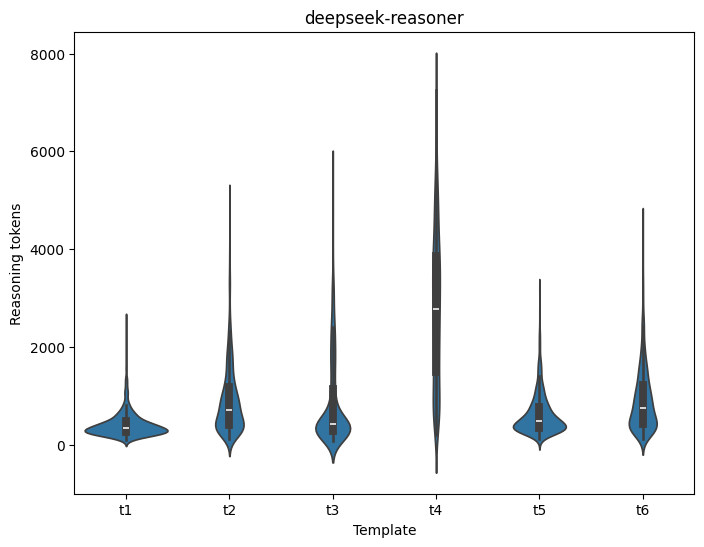

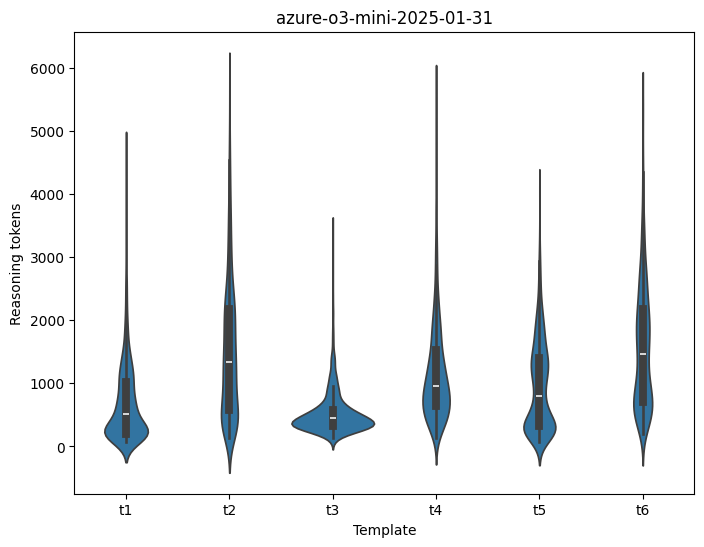

In [7]:
for model in df['model'].unique():
    plot_template_violin(df[df['model'] == model], model)